In [30]:
import numpy as np
import matplotlib.pyplot as plt
from pr_chain.utils.constants import C
from pr_chain.utils.plotting import add_detections, plot_caf
from pr_chain.processing import compute_caf, block_lattice_filter, apply_w, ca_cfar_1d
from pr_chain.generators import ClutterGenerator, EchoGenerator


In [62]:
N = 500000  # Number of samples


Np = 200
fs = 8e6
f_c = 700e6
wavelength = C / f_c
N_ch = 1

V_b = np.array([10, 100])  # Target velocity (m/s)

P_transmitter = np.array([0, 0])  # Transmitter position
P_radar = np.array([70, 150])  # Radar position
P_target = np.array([20, 220])  # Target position at time 0


reference_signal = np.random.randn(N) + 1j * np.random.randn(N)  # Complex white Gaussian noise as reference signal

clutter_gen = ClutterGenerator(
        fs = fs,
        N_CLUTT = 20,
        clutter_rcs_min_db=0,
        clutter_rcs_max_db=0,
        clutter_limits = np.array([-10, 500, 5, 150]),
        Tx_position = P_transmitter,
        Rx_position = P_radar
    )
echo_gen = EchoGenerator(
        fs = fs,
        f_c =  f_c,
        V_b = V_b,
        add_noise = False,
        rand_target= False,
        target_rcs_db=-3,
        target_position = P_target,
        Tx_position = P_transmitter,
        Rx_position = P_radar
)
clutter = clutter_gen.generate(reference_signal)
echo, f_D = echo_gen.generate(reference_signal)
surv = echo + clutter

In [63]:
caf, f, r = compute_caf(batch=Np, fs=fs, surveillance= surv, reference= reference_signal)


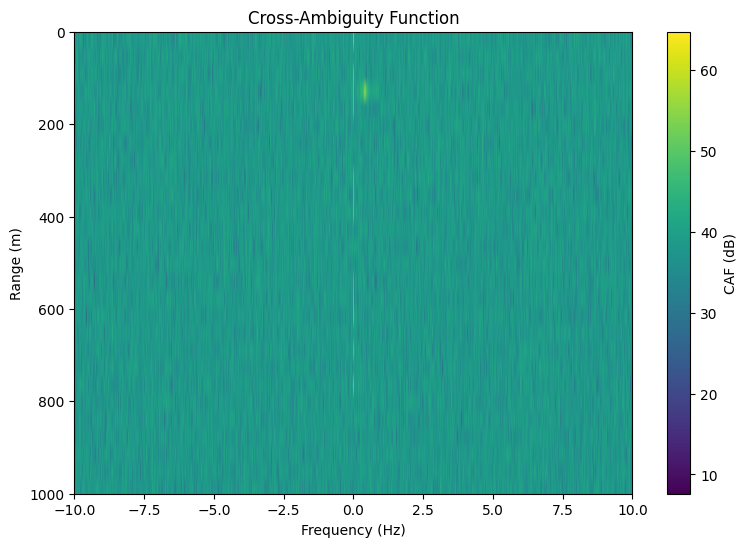

In [64]:

extent = [f[0] / 1e3, f[-1] / 1e3, r[-1], r[0]]
fig, ax = plot_caf(caf, extent, db=True, aspect="auto", cmap="viridis")
plt.xlim(-10, 10)
plt.ylim(1000, 0)
plt.show()


In [69]:
filtered_surv = block_lattice_filter(surveillance=echo+clutter, reference=reference_signal, order=30)
caf_filtered_w, _, _ = compute_caf(batch=Np, fs=fs, surveillance=filtered_surv, reference=apply_w(reference_signal, beta=(14.0, 14.0), freq=True, range=False))
caf_filtered, _, _ = compute_caf(
    batch=Np,
    fs=fs,
    surveillance=filtered_surv,
    reference= reference_signal
)

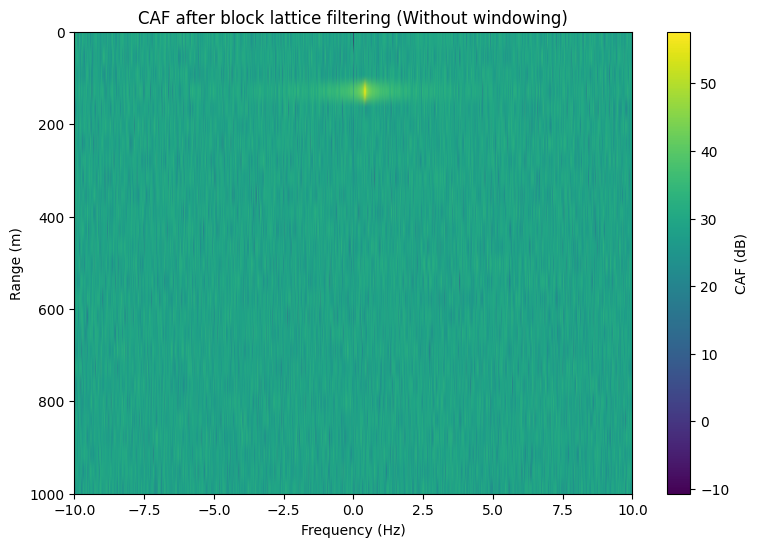

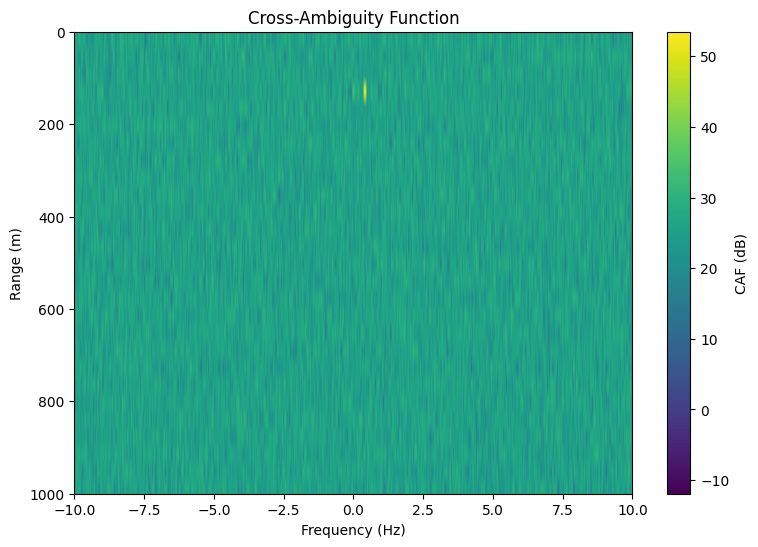

In [70]:
fig2, ax2 = plot_caf(caf_filtered, extent, db=True, aspect="auto", cmap="viridis")
plt.xlim(-10, 10)
plt.ylim(1000, 0)
ax2.set_title("CAF after block lattice filtering (Without windowing)")

fig3, ax3 = plot_caf(caf_filtered_w, extent, db=True, aspect="auto", cmap="viridis")
plt.xlim(-10, 10)
plt.ylim(1000, 0)
plt.show()


In [71]:
Nw = 512
Ng = 8
P_fa = 1e-6
detection_w = ca_cfar_1d(np.abs(caf_filtered_w), Nw, Ng, P_fa)
detection = ca_cfar_1d(np.abs(caf_filtered), Nw, Ng, P_fa)


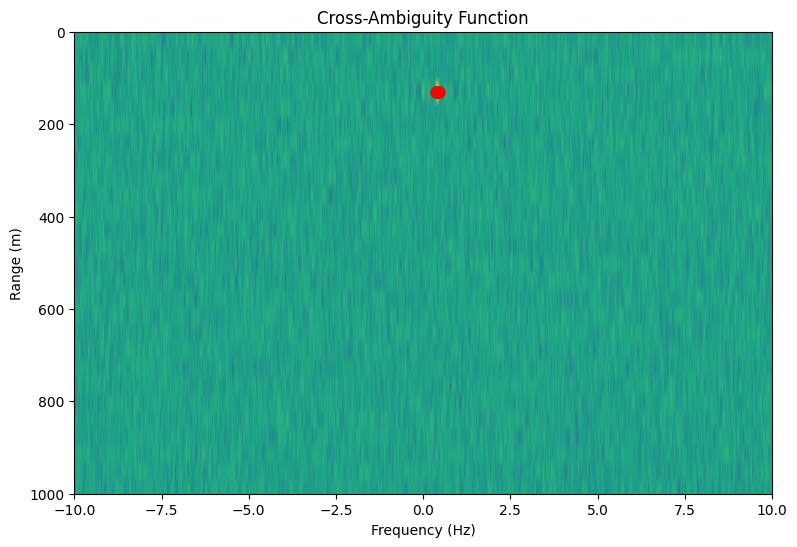

In [72]:
fig4, ax4 = add_detections(fig3, detection_w, caf_filtered.shape, extent)
plt.show()